<a href="https://colab.research.google.com/github/stereifberger/recursion_deep_learnig/blob/main/recursion_with_deep_learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Overview
An enviroment to train and evaluate neural networks on rule learning. The language used is stated in the notions of Chomsky.
- Terminal symbols (encoded as integers)
- Nonterminalsymbols and production rules (encoded as lambda-functions)

This is how it works:
1. Section "Libraries and utilities imports libraries and defines useful functions.
2. Section "Data generation" defines functions and a class for generating the training data
3. Section "Networks" defines a function that implements different network architectures.
4. Uses the before defined functions and Derivation class.
  a. "get_training_data()" produces data using the grammar and logic for building derivations in the Derivation class the nonterminals and production rules used by "nonterms()".
  b. A loop using "evaluate()" trains all specified architectures on the data and plots the results.

---

Open issues:
1. Sometimes still inhomogonous data is produced and the last cell has to be run several times until no error is produced. This will be fixed.
2. The environment is not as modular as I hoped it to be. Especially the specification of the grammar is split between the Derivation class and the "nonterms()" function.


# Libraries and utilities

In [ ]:
from keras.models import Sequential, Model
from keras.layers import Input, Dense, SimpleRNN, TimeDistributed, LSTM, RepeatVector
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
import random as rd
from random import seed, randint, choice, shuffle
import numpy as np
from numpy import argmax
import pandas as pd
from tqdm import tqdm
import copy
import re

In [ ]:
"""Flatten a matrix to one dimension."""
def flatten(matrix = list):
  return(list(pd.core.common.flatten(matrix)))

In [ ]:
"""Pad sublists of lists to same length. Necessary because in the task the
output is longer than the input which is not possible in some architectures."""
def pad(list_1 = list, list_2 = list):
  for sublist in tqdm(list_1, desc="Padded exmaples from X"):
    while len(sublist) < len(max(list_2, key = len)):
      sublist.append(0)
  for sublist in tqdm(list_2, desc="Padded exmaples from y"):
    while len(sublist) < len(max(list_2, key = len)):
      sublist.append(0)
  return list_1, list_2

In [ ]:
"""Flatten all subsets of a list"""
def out(y):
  new = []
  for x in y:
    x = flatten(x)
    new.append(x)
  return new

In [ ]:
"""The second function uses the first to partition lists into subsets of length n.
(https://www.geeksforgeeks.org/python-program-to-get-all-subsets-of-given-size-of-a-set/)"""
def subsets(numbers):
    if numbers == []:
        return [[]]
    x = subsets(numbers[1:])
    return x + [[numbers[0]] + y for y in x]

def subsets_with_length(numbers, n):
    return [x for x in subsets(numbers) if len(x)==n]

In [ ]:
"""Numbers in list encoded as str or int are listed as single digit ints."""
def to_int(data = list):
  new_data = [0]
  for i in data:
    for t in str(i):
      new_data.append(int(t))
    new_data.append(0)
  return new_data

# Data generation

In [ ]:
def apply_nonterms(term_num, args):
  derivations = []
  r1 = lambda term1: f"{term_num + 2}{term1}"
  r2 = lambda term1: f"{3}{term1}"
  r3 = lambda term1: f"{4}"

  found = False
  nr = 0
  for arg in args:
    #if str(arg)[:2] == f"""{symbol["NOT"]}{symbol["NOT"]}""":
      #[derivations.extend(notnotb(args)) for arg in args]
    derivations.append(r1(arg))
    derivations.append(r2(arg))
    derivations.append(r3(arg))

  derived = rd.choice(derivations)
  global max_num
  max_num = term_num + 2
  return derived, max_num

In [ ]:
def apply_nonterms(term_num, args):
  derivations = []
  r1 = lambda term1: f"{term_num + 2}{term1}"
  r2 = lambda term1: f"{term1}{term_num + 2}"
  r3 = lambda term1, term2: f"{term_num + 2}{term1}{term2}{term_num + 2}"

  found = False
  nr = 0
  for arg in args:
    #if str(arg)[:2] == f"""{symbol["NOT"]}{symbol["NOT"]}""":
      #[derivations.extend(notnotb(args)) for arg in args]
    derivations.append(r1(arg))
    derivations.append(r2(arg))
  if len(args) >= 2:
    derivations.append(r3(*args))

  derived = rd.choice(derivations)
  global max_num
  max_num = term_num + 3
  return derived, max_num

In [ ]:
"""A class for generating premises and derivations to conclusions.
Variables:
  - term_num: The number of terminal symbols
  - premises: The premises of a given derivation.
  - iter_range: Number span from which the number of iterations
    with which nonterminals are applied is randomly choosen.
  - sample_size: Number of dervations generated.
  - span_arg_num: Number span from which the number of generated
    premises is randomly chosen."""

class Derivation:
  def __init__(self,
               term_num = int,
               premises = list,
               iter_range = list,
               sample_size = int,
               span_arg_num = list):
    self.term_num = term_num
    self.terms = list(range(1, term_num + 1))
    self.iter_range = iter_range
    self.sample_size = sample_size
    self.span_arg_num =  span_arg_num
    self.premises = self.premises_gen()
    self.recursion_task = self.recursion_task()

  """Generates the premises."""
  def premises_gen(self):
    arg_num = rd.randint(*self.span_arg_num)
    arguments = rd.sample(self.terms, arg_num)
    # Optionally some logic for building well formed formulas.
    return arguments

  """When used with the Derivation method it returns:
    - X: The input to a network of the form [PREMISES, DELIMITER, CONCLUSION]
    - y: The output to a network of the form
      [PREMISES, DERIVATION STEP 1,..., DERIVATION STEP N, CONCLUSION]"""
  def recursion_task(self):
    X, y = [], []
    bar = tqdm(total=self.sample_size, desc="Generating example derivations")
    while len(X) < self.sample_size:
      derivation = self.premises_gen()
      if len(self.iter_range) == 2:
        iterations = range(rd.randint(*self.iter_range))
      else:
        iterations = self.iter_range
      premise = copy.copy(derivation)
      for iteration in iterations:
        if len(flatten(derivation)) >= 2:
          args = rd.sample(flatten(derivation), rd.randint(1,2))
        else:
          args = rd.sample(flatten(derivation), 1)
        derived, max_num = apply_nonterms(self.term_num, args)
        derivation.append(derived)
      conclusion = derivation[-1]
      X_new = to_int(flatten([premise, self.term_num + 1, conclusion]))
      #print(f"X_new:{X_new}")
      y.append(to_int(flatten(derivation)))

      X.append(X_new)
      bar.update(1)
    bar.close()
    return X, y, max_num

In [ ]:
"""Filters the training and testing examples to the shortest
derivations from a given set of premises and conclusions."""
def filter(X, y): # (Begin GPT, modified my the author)
  X_new = []
  y_new = []
  len_y = []
  for i in tqdm(range(len(X)), desc ="Filtered derivation examples"):
    potential = []
    t = 0
    while t < len(X):
      if X[t] == X[i]:
        potential.append(t)
      t += 1
    potential_strings = [y[i] for i in potential]
    index_of_shortest_string = potential[potential_strings.index(min(potential_strings, key=len))] # End GPT
    if X[index_of_shortest_string] not in X_new:
      X_new.append(X[index_of_shortest_string])
      y_new.append(y[index_of_shortest_string])
    len_y.append(len(y[i]))

  return X_new, y_new, len_y

# Networks

In [ ]:
architectures = ['forward', 'rnn', 'lstm']

In [ ]:
"""A function with witch architecture and parameters are selected.
Variables:
  - architecture: The name of the chosen architecture, for example "lstm".
  - num_hidden: Number of hidden layers.
  - num_hidden_dim: Number of neurons in each hidden layer.
  - func: The activation function used for neurons.
  - dim1, dim2: The first and second dimension of the test and training data.
    First dimension: How many symbols the training/test examples are long each.
    Second dimension: The length of the one-hot-encoding.
"""
def change_model(architecture = str,
                 num_hidden = int,
                 num_hidden_dim = int,
                 func = str,
                 dim1 = int,
                 dim2 = int):

  model = Sequential()
  if architecture == "forward":
    print(f"d1:{dim1}")
    print(f"d2:{dim2}")
    model.add(Dense(10,
                    input_dim = dim1*dim2,
                    activation = func))
    for i in range(num_hidden): # (Loop by GPT)
      model.add(Dense(num_hidden_dim,
                      activation = func))
    model.add(Dense(dim1*dim2,
                    activation=func))

  if architecture == "rnn":
    model.add(SimpleRNN(10,
                        input_shape = (dim1,dim2),
                        return_sequences = True))
    for i in range(num_hidden): # (Loop by GPT)
      model.add(SimpleRNN(num_hidden_dim - 1,
                          activation = func,
                          return_sequences = True))
    model.add(SimpleRNN(num_hidden_dim,
                        return_sequences = False))
    model.add(Dense(dim1*dim2,
                    activation = 'sigmoid'))
    model.build()

  if architecture == "lstm":
    model.add(LSTM(10,
                   input_shape = (dim1,dim2)))
    for i in range(num_hidden): # (Loop by GPT)
      model.add(Dense(num_hidden_dim,
                      activation = func))
    model.add(Dense(dim1*dim2))
  return model

# Experiments

In [ ]:
"""Uses "get_training_data()" to generates input and output data,
which is padded to the same length with zeros, one-hot encoded
and spilt into raining and test datasets."""

def get_training_data(term_num = int,
          span_arg_num = list,
          iter_range = list,
          sample_size = int,
          ):

  X, y, max_num = Derivation(term_num=term_num,
                    iter_range=iter_range,
                    sample_size=sample_size,
                    span_arg_num=span_arg_num).recursion_task
  X, y, len_y = filter(X, y)
  global X_copy
  global y_copy
  X_copy = X
  y_copy = y
  plot_l(X)
  X, y = pad(X, y)
  #for i in X:
   # if len(i) > 20:
    #  print(i)
  print(X)
  print(y)
  X = to_categorical(X, max_num)
  y = to_categorical(y, max_num)
  y = out(y)
  X_train = np.array(X)
  y_train = np.array(y)
  #X = np.array(X)
  #y = np.array(y)
  print(f"Sample size: {len(X)}")
  X_train,X_test,y_train,y_test = train_test_split(X,y,test_size = 0.1)
  #X_train,X_test,y_train,y_test = custom_split(X, y, len_y, 16)
  print(len(X_train),len(X_test),len(y_train),len(y_test))
  return X_train,X_test,y_train,y_test

In [ ]:
"""Takes the training data with all variables, relevant for training,
compiles a model with the architecture specified in the architecture variable,
and returns the history of the training."""

def evaluate(X_train = list,
            X_test = list,
            y_train = list,
            y_test = list,
            architecture = str,
            epochs = int,
            loss = str,
            metrics = list,
            num_hidden = int,
            num_hidden_dim = int,
            func = str):
  dim1 = X_train.shape[1]
  dim2 = X_train.shape[2]
  if architecture == "forward":
    X_train = np.array(out(X_train))
    X_test = np.array(out(X_test))
  global model
  model = change_model(architecture, num_hidden, num_hidden_dim, func, dim1, dim2)
  model.compile(loss=loss, optimizer='adam', metrics=metrics)
  history = model.fit(X_train, y_train, validation_data = (X_test,y_test), epochs=epochs, batch_size = 64)
  evaluation = model.evaluate(X_test,y_test)
  return history, evaluation

In [ ]:
import matplotlib.pyplot as plt # all GPT
def plot_l(data_list):
  # Count the number of elements in each sublist
  length_counts = {}
  for sublist in data_list:
      length = len(sublist)
      if length in length_counts:
          length_counts[length] += 1
      else:
          length_counts[length] = 1

  # Create lists for plotting
  lengths = list(length_counts.keys())
  counts = list(length_counts.values())

  # Plotting the bar diagram
  plt.bar(lengths, counts, color='blue')
  plt.xlabel('Length of derivations')
  plt.ylabel('Number of derivations')
  plt.title('Task 2: Number of derivations of given length')
  plt.show()

In [ ]:
def part(array, size=10):
    return [array[i:i + size] for i in range(0, len(array), size)]

Filtered derivation examples: 100%|██████████| 20/20 [00:00<00:00, 97541.95it/s]


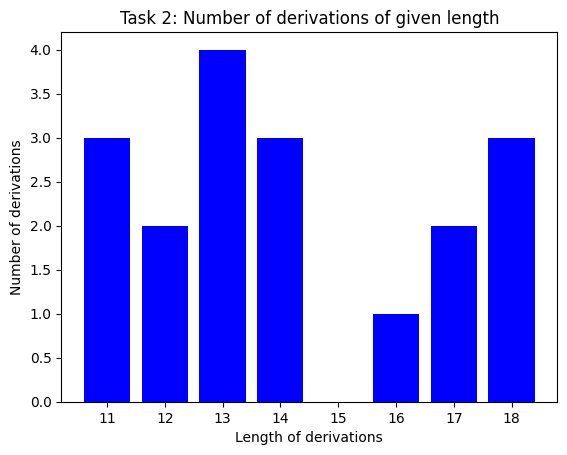

Padded exmaples from y: 100%|██████████| 18/18 [00:00<00:00, 57763.94it/s]

[[0, 6, 0, 5, 0, 7, 0, 8, 6, 1, 1, 5, 8, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 1, 0, 6, 0, 7, 0, 9, 9, 8, 8, 1, 1, 1, 4, 8, 8, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 1, 0, 7, 0, 8, 8, 1, 1, 1, 3, 8, 1, 1, 4, 8, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 5, 0, 1, 0, 7, 0, 9, 9, 8, 5, 8, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 3, 0, 2, 0, 7, 0, 9, 9, 8, 3, 8, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 1, 0, 6, 0, 7, 0, 8, 1, 1, 2, 9, 9, 8, 6, 8, 8, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 6, 0, 7, 0, 8, 6, 1, 1, 4, 8, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 4, 0, 2, 0, 7, 0, 8, 2, 1, 1, 6, 8, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 6, 0, 7, 0, 9, 9, 8, 6, 8, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 4, 0, 7, 0, 9, 9, 8, 4, 8, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 1, 0, 6, 0, 7, 0, 9, 9, 8, 1, 8, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 6, 0, 1, 0, 7, 0

In [ ]:
X_train,X_test,y_train,y_test = get_training_data(term_num = 6,
        span_arg_num = [1,2],
        iter_range = [1,3],
        sample_size = 20)

In [ ]:
#GPT
import json

# Combine the lists into a dictionary
data = {
    "list1": X_train.tolist(),
    "list2": X_test.tolist(),
    "list3": y_train.tolist(),
    "list4": y_test.tolist()
}

# Specify the file path where you want to save the JSON file
file_path = "03-14_lists_data_50000_c.json"

# Write the data to a JSON file
with open(file_path, "w") as json_file:
    json.dump(data, json_file)

print("Lists saved to JSON successfully.")


In [ ]:
"""Here I bring everything together:
  1. Get training and testing data from "get_training_data()"
  2. Loops through all architectures and trains each on the
     data and returns the history
  3. Plots the training history

Notice, that sometimes still inhomogonous data is produced and the cell has to be
run several times until no error is produced. This will be fixed. """

all_histories = []
all_evaluations = []
for a in architectures:
  history, evaluation = evaluate(X_train,
          X_test,
          y_train,
          y_test,
          architecture = a,
          epochs = 100,
          loss = 'mse',
          metrics=['mae', 'acc'],
          num_hidden = 3,
          num_hidden_dim = 200,
          func = 'sigmoid'
          )
  all_histories.append(history.history)
  all_evaluations.append(evaluation) # (Begin GPT)

In [ ]:
# Plotting
plt.figure(figsize=(10, 6))
for i, history in enumerate(all_histories):
    plt.plot(history['mae'], label=f'MAE {architectures[i]}')
#plt.title('Task 2: MAE training history')
plt.xlabel('Epochs')
plt.ylabel('ACC')
plt.legend()
plt.show() # (End GPT)

# Plotting
plt.figure(figsize=(10, 6))
for i, history in enumerate(all_histories):
    plt.plot(history['val_mae'], label=f'VAL_MAE {architectures[i]}')
plt.title('Task 2: MAE on test data')
plt.xlabel('Epochs')
plt.ylabel('MAE')
plt.legend()
plt.show() # (End GPT)

plt.figure(figsize=(10, 6))
for i, history in enumerate(all_histories):
    plt.plot(history['loss'], label=f'Loss {architectures[i]}')
plt.title('Task 2: Loss training history')
plt.xlabel('Epochs')
plt.ylabel('LOSS')
plt.legend()
plt.show() # (End GPT)